In [ ]:
# Final Project: Quantitative Time-Series Analysis & Modeling
## Sector ETF Analysis: XLK, XLE, and XLF
### Author: Andrew Rush

In [ ]:
## Introduction

##This project analyzes three sector ETFs: XLK (Technology), XLE (Energy), and XLF (Financials).
## The goal is to clean and preprocess historical time-series data, explore return behavior and volatility patterns, and apply a forecasting model to evaluate predictive performance.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [ ]:
## Data Collection

## Historical daily ETF data was downloaded from Yahoo Finance using the yfinance Python package. The sample begins on January 1, 2019.

In [ ]:
tickers = ['XLK', 'XLE', 'XLF']
data = yf.download(tickers, start='2019-01-01')
data.head()

/tmp/ipykernel_8152/2995963768.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2019-01-01')
[*********************100%***********************]  3 of 3 completed


Price           Close                             High                        \
Ticker            XLE        XLF        XLK        XLE        XLF        XLK   
Date                                                                           
2019-01-02  21.123751  20.933632  29.032200  21.264624  20.977207  29.205400   
2019-01-03  20.914248  20.463003  27.567020  21.261012  20.829037  28.311316   
2019-01-04  21.625839  21.142788  28.788782  21.690858  21.186363  28.910490   
2019-01-07  21.947317  21.168928  29.046244  22.106252  21.360659  29.242851   
2019-01-08  22.117085  21.186359  29.289658  22.304916  21.395521  29.430090   

Price             Low                             Open                        \
Ticker            XLE        XLF        XLK        XLE        XLF        XLK   
Date                                                                           
2019-01-02  20.282125  20.393296  28.381527  20.386875  20.454301  28.418975   
2019-01-03  20.675847  20.410713  27.529573  21.185157  20.776747  28.292591   
2019-01-04  21.152651  20.759324  27.983632  21.275463  20.811614  28.072574   
2019-01-07  21.499413  20.968480  28.723248  21.788384  21.099206  28.788783   
2019-01-08  21.997885  20.942338  28.943257  22.254346  21.360662  29.327107   

Price         Volume                      
Ticker           XLE       XLF       XLK  
Date                                      
2019-01-02  49785200  62945000  30885800  
2019-01-03  36048200  65729700  49893400  
2019-01-04  42703000  64638400  41535600  
2019-01-07  36113400  48167000  23817200  
2019-01-08  37384600  90114700  26005200

In [ ]:
## Data Cleaning and Preprocessing

## Closing prices were extracted, sorted by date, checked for missing values, and daily percentage returns were calculated.

In [ ]:
prices = data['Close'].copy()
prices = prices.sort_index()
prices = prices.dropna()

returns = prices.pct_change().dropna()

print(prices.head())
print(returns.head())

Ticker            XLE        XLF        XLK
Date                                       
2019-01-02  21.123751  20.933632  29.032200
2019-01-03  20.914248  20.463003  27.567020
2019-01-04  21.625839  21.142788  28.788782
2019-01-07  21.947317  21.168928  29.046244
2019-01-08  22.117085  21.186359  29.289658
Ticker           XLE       XLF       XLK
Date                                    
2019-01-03 -0.009918 -0.022482 -0.050467
2019-01-04  0.034024  0.033220  0.044320
2019-01-07  0.014865  0.001236  0.008943
2019-01-08  0.007735  0.000823  0.008380
2019-01-09  0.015842  0.004936  0.012946


In [ ]:
## Exploratory Data Analysis

## The first visualization compares the growth of a hypothetical $100 investment across all three ETFs.

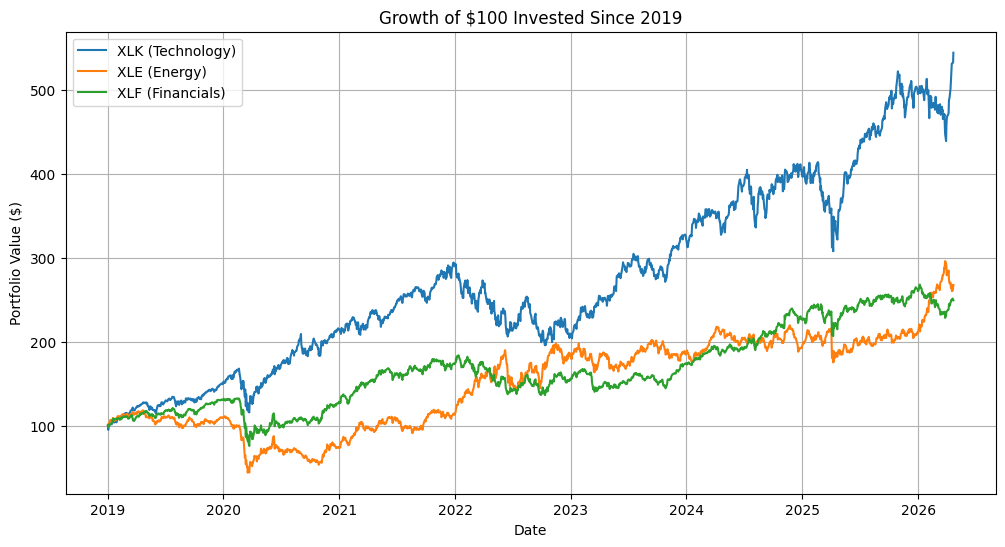

In [ ]:
normalized = prices / prices.iloc[0] * 100

plt.figure(figsize=(12,6))
plt.plot(normalized.index, normalized['XLK'], label='XLK (Technology)')
plt.plot(normalized.index, normalized['XLE'], label='XLE (Energy)')
plt.plot(normalized.index, normalized['XLF'], label='XLF (Financials)')

plt.title('Growth of $100 Invested Since 2019')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## Technology significantly outperformed the other sectors over the sample period, while Energy showed more cyclical behavior.

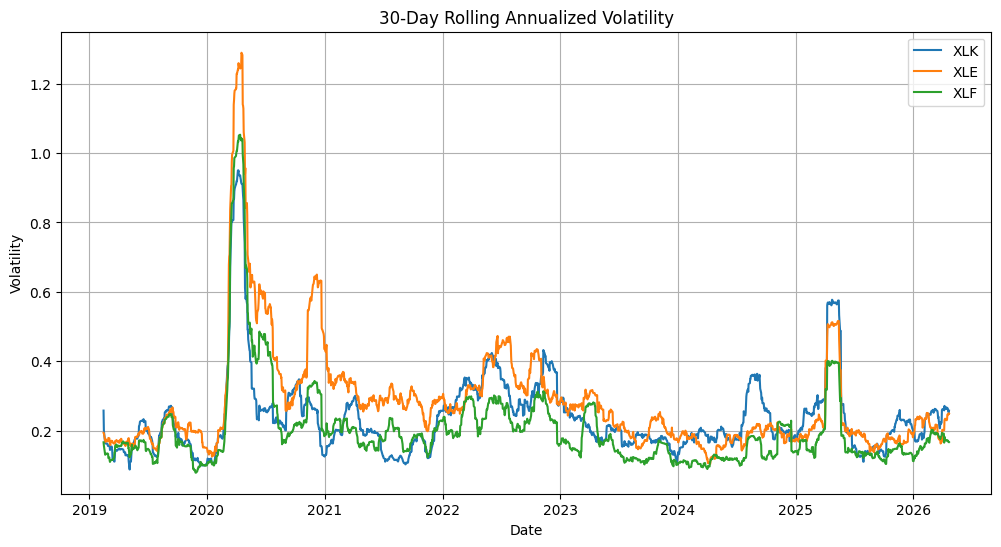

In [ ]:
rolling_vol = returns.rolling(30).std() * np.sqrt(252)

plt.figure(figsize=(12,6))
plt.plot(rolling_vol.index, rolling_vol['XLK'], label='XLK')
plt.plot(rolling_vol.index, rolling_vol['XLE'], label='XLE')
plt.plot(rolling_vol.index, rolling_vol['XLF'], label='XLF')

plt.title('30-Day Rolling Annualized Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## Rolling volatility highlights periods of market stress, especially during the 2020 COVID shock and later inflation-driven volatility.

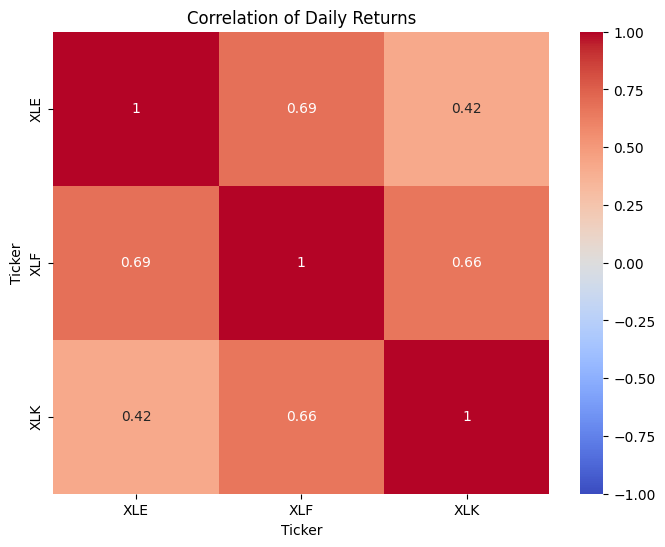

In [ ]:
corr = returns.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)

plt.title('Correlation of Daily Returns')
plt.show()

In [ ]:
## All three ETFs were positively correlated, though Energy showed lower correlation with Technology than the other pairings.

In [ ]:
## Forecasting Model

## Exponential Smoothing was used to forecast XLK prices. The final 60 trading days were reserved as a test set.

In [ ]:
xlk = prices['XLK']

train = xlk[:-60]
test = xlk[-60:]

model = ExponentialSmoothing(train, trend='add', seasonal=None)
fit = model.fit()

forecast = fit.forecast(60)

rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 9.06208274319284
MAE: 7.988602364586088


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


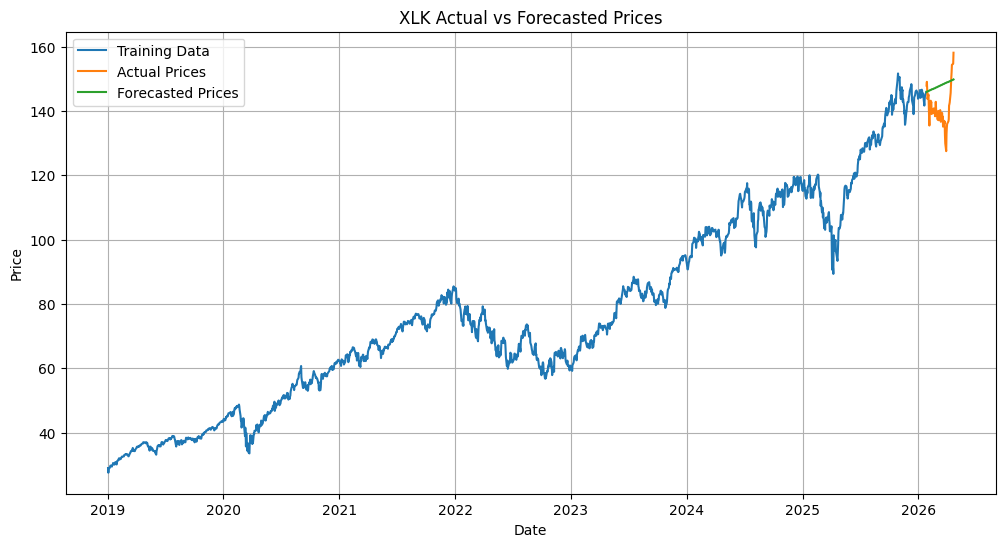

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Prices')
plt.plot(test.index, forecast, label='Forecasted Prices')

plt.title('XLK Actual vs Forecasted Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
## The model captured the general upward trend of XLK prices but was less accurate in predicting short-term market fluctuations.

In [ ]:
## Conclusion

## This project demonstrated how time-series financial data can be cleaned, analyzed, and modeled using Python.
## XLK delivered the strongest long-term returns, XLE showed the highest volatility, and all three sectors displayed meaningful positive correlations.
## The forecasting model performed reasonably well in identifying trend direction, though daily market noise limited predictive precision.

In [ ]:
prices.to_csv("sector_etf_data.csv")

In [1]:
from google.colab import files
files.download("sector_etf_data.csv")

FileNotFoundError: Cannot find file: sector_etf_data.csv